<a href="https://colab.research.google.com/github/hmdaalln/image-denoising-capstone/blob/main/Image_Denoising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Denoising

## Project Overview :
In this notebook, we prepare the SIDD dataset before training the image denoising model.
The goal is to understand the dataset structure and visualize noisy and clean images.

## Problem Statement

Image noise can reduce image quality and negatively affect many computer vision applications.

Our objective is to build a model that learns how to transform noisy images into clean images while keeping edges and textures as natural as possible.

## Project Objectives

The main objectives of this project are:

- Explore and understand the SIDD dataset.
- Prepare the dataset for training.
- Train a deep learning model for image denoising.
- Evaluate the model using PSNR and SSIM.
- Compare the model performance and visualize the results.

## Dataset Description

This project uses the Smartphone Image Denoising Dataset (SIDD).

The dataset contains pairs of noisy and clean images captured using different smartphones under various lighting conditions. It is specifically designed for image denoising tasks.

## Workflow
1. Import Libraries
2. Explore the Dataset
3. Data Preprocessing
4. Create DataLoaders

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## 1. Import Libraries

In [8]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import copy
import time
import pandas as pd

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.transforms import functional as TF
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

## 2. Dataset Exploration

In this section, we explore the SIDD dataset to understand its structure and examine a sample pair of noisy and clean images before training the model.

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
# Extract the dataset
zip_path = "/content/drive/MyDrive/Capstone_Project/SIDD_Small_sRGB_Only.zip"
extract_path = "/content/SIDD"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [33]:
# Path to the extracted dataset
dataset_path = "/content/SIDD/SIDD_Small_sRGB_Only/Data"

# Read all folders
image_folders = os.listdir(dataset_path)

print("Number of samples:", len(image_folders))
print("First sample folder:", image_folders[0])
print("Second  sample folder:", image_folders[1])

Number of samples: 160
First sample folder: 0160_007_IP_00400_00400_3200_L
Second  sample folder: 0193_009_IP_00800_02000_3200_N


In [34]:
# Open one sample folder
sample_image = os.path.join(dataset_path, image_folders[2])

# Show the files inside the scene
files = os.listdir(sample_image)

print("Files in the first sample:")
print(files)

Files in the first sample:
['NOISY_SRGB_010.PNG', 'GT_SRGB_010.PNG']


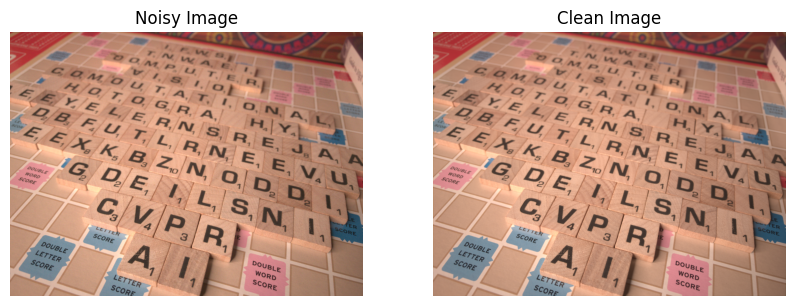

In [35]:
# Read the images
noisy_image = Image.open(os.path.join(sample_image, "NOISY_SRGB_010.PNG"))
clean_image = Image.open(os.path.join(sample_image, "GT_SRGB_010.PNG"))

# Display the images
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(noisy_image)
plt.title("Noisy Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(clean_image)
plt.title("Clean Image")
plt.axis("off")

plt.show()

### Observation

The SIDD dataset contains pairs of noisy and clean images. Each noisy image has a corresponding clean image that will be used as the target during model training.

## 3. Data Preprocessing
In this section, we prepare the SIDD image pairs for model training.  
First, we split the sample folders into training, validation, and testing sets.  
The images will later be converted into smaller patches and normalized.

In [36]:
from sklearn.model_selection import train_test_split

# Split the folders into training and remaining data
train_folders, temp_folders = train_test_split(
    image_folders,
    test_size=0.30,
    random_state=42
)

# Split the remaining folders into validation and testing
val_folders, test_folders = train_test_split(
    temp_folders,
    test_size=0.50,
    random_state=42
)

# Check the number of samples in each set
print("Training samples:", len(train_folders))
print("Validation samples:", len(val_folders))
print("Testing samples:", len(test_folders))

Training samples: 112
Validation samples: 24
Testing samples: 24


### Prepare the Image Pairs

In this step, we create a dataset class to load each noisy image with its matching clean image. We also crop the same area from both images and convert them into tensors.

In [70]:
class SIDDDataset(Dataset):

    def __init__(
        self,
        dataset_path,
        folders,
        patch_size=128,
        patches_per_image=8,
        augment=False

    ):
        # Save dataset information
        self.dataset_path = dataset_path
        self.folders = folders
        self.patch_size = patch_size
        self.patches_per_image = patches_per_image
        self.augment = augment


    def __len__(self):
        # Each image folder can generate several random patches
        return len(self.folders) * self.patches_per_image

    def __getitem__(self, index):

        # Identify which image folder to use
        folder_index = index // self.patches_per_image

        # Open one sample folder
        sample_path = os.path.join(
            self.dataset_path,
            self.folders[folder_index]
        )

        # Find the noisy and clean image files
        files = os.listdir(sample_path)

        noisy_file = [f for f in files if "NOISY" in f][0]
        clean_file = [f for f in files if "GT" in f][0]

        # Open the noisy image
        noisy_image = Image.open(
            os.path.join(sample_path, noisy_file)
        ).convert("RGB")

        # Open the clean image
        clean_image = Image.open(
            os.path.join(sample_path, clean_file)
        ).convert("RGB")

        # Select the same random crop coordinates
        i, j, h, w = transforms.RandomCrop.get_params(
            noisy_image,
            output_size=(
                self.patch_size,
                self.patch_size
            )
        )

        # Crop the same area from both images
        noisy_image = TF.crop(noisy_image, i, j, h, w)
        clean_image = TF.crop(clean_image, i, j, h, w)

        # Apply paired data augmentation
        if self.augment:

            # Random horizontal flip
            if torch.rand(1).item() > 0.5:
                noisy_image = TF.hflip(noisy_image)
                clean_image = TF.hflip(clean_image)

            # Random vertical flip
            if torch.rand(1).item() > 0.5:
                noisy_image = TF.vflip(noisy_image)
                clean_image = TF.vflip(clean_image)

        # Convert images to tensors
        noisy_image = TF.to_tensor(noisy_image)
        clean_image = TF.to_tensor(clean_image)

        # Calculate the true noise residual
        noise_target = noisy_image - clean_image

        # Return the tensors
        return {
            "noisy": noisy_image,
            "clean": clean_image,
            "noise_target": noise_target
        }

In [71]:
# Create the dataset
train_dataset = SIDDDataset(
    dataset_path,
    train_folders,
    patch_size=128,
    patches_per_image=8,
    augment=True
)
# Get one sample
sample = train_dataset[0]

# Check the output
print("Noisy shape:", sample["noisy"].shape)
print("Clean shape:", sample["clean"].shape)
print("Noise target shape:", sample["noise_target"].shape)

Noisy shape: torch.Size([3, 128, 128])
Clean shape: torch.Size([3, 128, 128])
Noise target shape: torch.Size([3, 128, 128])


## 4. Create DataLoaders
In this step, we create DataLoaders for the training, validation, and testing datasets. The DataLoader loads the images in batches during training.

In [50]:
# Create the datasets
train_dataset = SIDDDataset(dataset_path, train_folders)
val_dataset = SIDDDataset(dataset_path, val_folders)
test_dataset = SIDDDataset(dataset_path, test_folders)

In [51]:
# Create the dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

In [57]:
# Check one batch
batch = next(iter(train_loader))

noisy_batch = batch["noisy"]
clean_batch = batch["clean"]
noise_target_batch = batch["noise_target"]

print("Noisy batch:", noisy_batch.shape)
print("Clean batch:", clean_batch.shape)
print("Noise target:", noise_target_batch.shape)

Noisy batch: torch.Size([8, 3, 128, 128])
Clean batch: torch.Size([8, 3, 128, 128])
Noise target: torch.Size([8, 3, 128, 128])


## 6. Build and Train the DnCNN Model


---


In this section, we build the DnCNN model and prepare it for training.

**DnCNN** uses residual learning. Instead of predicting the clean image directly, the model predicts the noise contained in the image.

The true noise residual is calculated as:

$$
\text{Noise Target}
=
\text{Noisy Image}
-
\text{Clean Image}
$$

The denoised image is calculated as:

$$
\text{Denoised Image}
=
\text{Noisy Image}
-
\text{Predicted Noise}
$$

This approach allows the model to learn the noise present in the image rather than predicting the clean image directly. After the model predicts the noise residual, the denoised image is obtained by subtracting the predicted noise from the noisy input.


## 6.1 Build the DnCNN Architecture

In [61]:
class DnCNN(nn.Module):

    def __init__(
        self,
        image_channels=3,
        depth=17,
        features=64
    ):
        super().__init__()

        layers = []

        # First convolution layer
        layers.append(
            nn.Conv2d(
                in_channels=image_channels,
                out_channels=features,
                kernel_size=3,
                padding=1,
                bias=True
            )
        )
        layers.append(nn.ReLU(inplace=True))

        # Middle convolution layers
        for _ in range(depth - 2):
            layers.append(
                nn.Conv2d(
                    in_channels=features,
                    out_channels=features,
                    kernel_size=3,
                    padding=1,
                    bias=False
                )
            )
            layers.append(nn.BatchNorm2d(features))
            layers.append(nn.ReLU(inplace=True))

        # Final convolution layer
        layers.append(
            nn.Conv2d(
                in_channels=features,
                out_channels=image_channels,
                kernel_size=3,
                padding=1,
                bias=True
            )
        )

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        predicted_noise = self.model(x)
        return predicted_noise

**Why this code?**

This code defines the architecture of the DnCNN model.

The model receives a noisy RGB image and predicts the noise residual contained in the image.

The first convolution layer extracts image features. The middle layers learn more complex noise patterns, and the final convolution layer produces the predicted noise.

**Step explanation**

- image_channels=3 means the input images are RGB.
- depth=17 creates 17 convolutional layers.
- features=64 means the hidden layers use 64 feature maps.
- kernel_size=3 applies a 3 × 3 filter.
- padding=1 keeps the image height and width unchanged.
- BatchNorm2d helps stabilize training.
- ReLU introduces non-linearity.
- The final layer outputs three channels.

**What did we notice?**

The model accepts a three channel RGB image and produces a three channel predicted noise image.

The final layer does not use ReLU because the noise residual may contain both positive and negative values.

## 6.2. Test the Model with  a Random Tensor

In [62]:
test_model = DnCNN()

x = torch.randn(
    8,
    3,
    128,
    128
)

y = test_model(x)

print("Input shape:", x.shape)
print("Output shape:", y.shape)

torch.Size([8, 3, 128, 128])


**Why this code?**

This code tests the model using a randomly generated tensor before using real images.

It confirms that the model architecture does not contain channel or dimension errors.

**Step explanation**

- 8 is the batch size.
- 3 is the number of RGB channels.
- 128 × 128 is the patch size.
- The random tensor is passed through the model.
- The input and output shapes are printed.

**What did we notice?**

The input and output shapes are both:

**torch.Size([8, 3, 128, 128])**

This confirms that the predicted noise has the same shape as the noisy input image.

## 6.3. Select the device



In [72]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


**Why this code?**

This code checks whether a GPU is available.

A GPU can train the deep learning model faster than a CPU.

**Step explanation**

- torch.cuda.is_available() checks whether CUDA is available.
- If CUDA is available, the device is set to cuda.
- Otherwise, the device is set to cpu.

**What did we notice?**

The output was:

**Device: cuda**

This means the notebook is using a GPU runtime.

The model and image batches must be moved to the same device.

## 6.4. Create the DnCNN Model


In [64]:
model = DnCNN(
    image_channels=3,
    depth=17,
    features=64
).to(device)

print(model)

DnCNN(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU(inplace=True)
    (5): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): Conv2d(64, 64, kernel_size=(3, 3), str

**Why this code?**

This cell creates the **DnCNN** model and moves it to the selected device.

**Step explanation**

- image_channels=3: the input images are RGB.
- depth=17: the network contains 17 convolutional layers.
- features=64: the hidden layers use 64 feature maps.
- .to(device) moves the model to the GPU or CPU.

**What did we notice?**

- The first layer converts three RGB channels into 64 feature maps.

- The middle layers process 64 feature maps.

- The final layer converts the 64 feature maps back into a three channel predicted noise image.

## 6.5. Count the Model Parameters

In [65]:
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Total parameters:", total_parameters)
print("Trainable parameters:", trainable_parameters)

Total parameters: 558403
Trainable parameters: 558403


**Why this code?**

This code calculates the total number of parameters in the model.

The parameter count helps us understand the size and complexity of DnCNN.

**Step explanation**

- model.parameters() accesses the model parameters.
- parameter.numel() counts the values in each parameter tensor.
- requires_grad checks whether the parameter will be updated during training.

**What did we notice?**

The model contains:

- Total parameters: 558403
- Trainable parameters: 558403

All model parameters are trainable.

## 6.6. Test the Forward Pass

In [66]:
batch = next(iter(train_loader))

noisy_batch = batch["noisy"].to(device)

with torch.no_grad():

    predicted_noise = model(noisy_batch)

print("Input shape:", noisy_batch.shape)
print("Predicted noise shape:", predicted_noise.shape)

Input shape: torch.Size([8, 3, 128, 128])
Predicted noise shape: torch.Size([8, 3, 128, 128])


**Why this code?**

This code tests the model using a real batch from the training DataLoader.

It confirms that the dataset, DataLoader, model, and device work together correctly.

**Step explanation**

- next(iter(train_loader)) loads one batch.
- batch["noisy"] retrieves the noisy images.
- .to(device) moves the images to the GPU or CPU.
- torch.no_grad() disables gradient calculations.
- The model predicts the noise residual.

**What did we notice?**

The input and predicted noise shapes are:

**torch.Size([8, 3, 128, 128])**

The predicted noise has the same shape as the true noise target, so they can be compared using the loss function.

## Training Setup and Training Loop


---


## 6.7. Define the Training Configuration

In [67]:
CONFIG = {
    "learning_rate": 0.001,
    "epochs": 30,
    "early_stopping_patience": 5
}

**Why this code?**

This dictionary stores the main training settings in one place.

**Step explanation**

- learning_rate controls the size of the model updates.
- epochs defines the maximum number of training cycles.
- early_stopping_patience controls how long training waits when validation loss does not improve.

**What did we notice?**

- The initial learning rate is 0.001.

- The model can train for a maximum of 30 epochs.

- Training may stop early if validation loss does not improve for five consecutive epochs.

## 6.8. Create Output Folders

In [74]:
OUTPUT_ROOT = (
    "/content/drive/MyDrive/"
    "Capstone_Project/Image_Denoising_Results"
)

CHECKPOINT_ROOT = os.path.join(
    OUTPUT_ROOT,
    "checkpoints"
)

METADATA_ROOT = os.path.join(
    OUTPUT_ROOT,
    "metadata"
)

RESULTS_ROOT = os.path.join(
    OUTPUT_ROOT,
    "results"
)

os.makedirs(CHECKPOINT_ROOT, exist_ok=True)
os.makedirs(METADATA_ROOT, exist_ok=True)
os.makedirs(RESULTS_ROOT, exist_ok=True)

print("Output folders created successfully.")
print("Checkpoint folder:", CHECKPOINT_ROOT)
print("Metadata folder:", METADATA_ROOT)
print("Results folder:", RESULTS_ROOT)


Output folders created successfully.
Checkpoint folder: /content/drive/MyDrive/Capstone_Project/Image_Denoising_Results/checkpoints
Metadata folder: /content/drive/MyDrive/Capstone_Project/Image_Denoising_Results/metadata
Results folder: /content/drive/MyDrive/Capstone_Project/Image_Denoising_Results/results


**Why this code?**

This code creates folders for saving the model and project results.

The folders are stored in Google Drive so that the files remain available after the Colab session ends.

**Step explanation**

- The checkpoint folder stores trained models.
- The metadata folder stores training history and configuration.
- The results folder stores evaluation results and images.
exist_ok=True prevents an error if the folders already exist.

**What did we notice?**

- All output folders were created successfully inside Google Drive.

- The printed paths confirm where the model and results will be saved.

## 6.9. Define the Loss Function

In [75]:
criterion = nn.MSELoss()

**Why this code?**

The model predicts the noise residual.

MSE loss measures the average squared difference between the predicted noise and the true noise residual.

**Step explanation**

The loss is calculated using:

loss = criterion(
    predicted_noise,
    target_noise
)

A smaller loss means the predicted noise is closer to the true noise.

**What did we notice?**

- The MSE loss function was created successfully.

- No output is displayed because the loss value is calculated only when data is passed to the function.

## 6.10. Define the Optimizer

In [76]:
optimizer = Adam(
    model.parameters(),
    lr=CONFIG["learning_rate"]
)

**Why this code?**

The optimizer updates the model parameters during training.

Adam is commonly used because it provides stable and efficient parameter updates.

**Step explanation**

- model.parameters() gives Adam access to all trainable parameters.
- The learning rate is taken from the configuration dictionary.
- optimizer.step() updates the model after gradients are calculated.

**What did we notice?**

- The Adam optimizer was initialized successfully.

- The initial learning rate is 0.001

## 6.11. Define the Learning Rate Scheduler

In [77]:
scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

**Why this code?**

The scheduler reduces the learning rate when validation loss stops improving.

A smaller learning rate allows the optimizer to make smaller adjustments during later training stages.

**Step explanation**

- mode="min" means a smaller validation loss is better.
- factor=0.5 reduces the learning rate by half.
- patience=2 waits for two epochs without improvement.
- min_lr=1e-6 sets the minimum learning rate.

**What did we notice?**

- The scheduler was initialized successfully.

- No output is displayed because the scheduler will only change the learning rate after receiving validation-loss values.

## 6.12. Define the one Epoch Function

In [78]:
def run_epoch(
    model,
    loader,
    training
):

    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0
    total_samples = 0

    for batch in tqdm(
        loader,
        leave=False
    ):

        noisy = batch["noisy"].to(device)
        target_noise = batch[
            "noise_target"
        ].to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):

            predicted_noise = model(noisy)

            loss = criterion(
                predicted_noise,
                target_noise
            )

            if training:

                loss.backward()

                optimizer.step()

        batch_size = noisy.size(0)

        total_loss += (
            loss.item()
            * batch_size
        )

        total_samples += batch_size

    average_loss = (
        total_loss
        / total_samples
    )

    return average_loss

**Why this code?**

This function runs one complete pass through either the training or validation dataset.

It is used for both stages to avoid repeating similar code.

**Step explanation**

- model.train() enables training behavior.

- model.eval() changes the model to evaluation mode.

- optimizer.zero_grad() removes gradients from the previous batch.

- predicted_noise = model(noisy) performs the forward pass.

- loss.backward() calculates gradients.

- optimizer.step() updates the model weights.


**What did we notice?**

- The same function can be used for training and validation.

- During training, gradients are calculated and the model weights are updated.

- During validation, gradients are disabled and no model updates are performed.

## 6.13. Train the Model & Save the Best Checkpoint

In [ ]:
history = []

best_val_loss = float("inf")
patience_counter = 0

best_model_path = os.path.join(
    CHECKPOINT_ROOT,
    "dncnn_best.pth"
)

for epoch in range(
    1,
    CONFIG["epochs"] + 1
):

    start_time = time.perf_counter()

    train_loss = run_epoch(
        model,
        train_loader,
        training=True
    )

    val_loss = run_epoch(
        model,
        val_loader,
        training=False
    )

    scheduler.step(val_loss)

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )

    epoch_time = (
        time.perf_counter()
        - start_time
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "learning_rate": current_lr,
        "time_seconds": epoch_time
    })

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.3f} | "
        f"Validation Loss: {val_loss:.3f} | "
        f"LR: {current_lr:.2e} | "
        f"Time: {epoch_time:.1f}s"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "validation_loss": val_loss,
                "config": CONFIG
            },
            best_model_path
        )

        print("Best model saved.")

    else:

        patience_counter += 1

    if (
        patience_counter
        >= CONFIG[
            "early_stopping_patience"
        ]
    ):

        print("Early stopping triggered.")

        break


  0%|          | 0/112 [00:00<?, ?it/s]

  0%|          | 0/24 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.010 | Validation Loss: 0.003 | LR: 1.00e-03 | Time: 1038.2s
Best model saved.


  0%|          | 0/112 [00:00<?, ?it/s]

  0%|          | 0/24 [00:00<?, ?it/s]

Epoch 02 | Train Loss: 0.004 | Validation Loss: 0.003 | LR: 1.00e-03 | Time: 1062.8s
Best model saved.


  0%|          | 0/112 [00:00<?, ?it/s]

  0%|          | 0/24 [00:00<?, ?it/s]

Epoch 03 | Train Loss: 0.003 | Validation Loss: 0.002 | LR: 1.00e-03 | Time: 1000.7s
Best model saved.


  0%|          | 0/112 [00:00<?, ?it/s]

**Why this code?**

This loop trains the model for several epochs.

After every epoch, it:

- Calculates training loss,
- Calculates validation loss,
- Updates the learning rate,
- Stores the results,
- Saves the best model,
- Checks whether early stopping is required.

**Why save the best model?**

The last epoch is not always the best one.

The model with the lowest validation loss is saved because it is expected to generalize better.

**Why early stopping?**

Early stopping prevents unnecessary training when validation performance no longer improves.

It may also reduce overfitting and save GPU time.

**What do we noticed?**

## 6.12. Save Training History

In [ ]:
history_df = pd.DataFrame(history)

history_path = os.path.join(
    METADATA_ROOT,
    "dncnn_training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)

history_df.tail()

**Why this code?**

The training results are stored in a table and saved as a CSV file.

The file can later be used in:

- The report,
- The presentation,
- Model comparison,
- GitHub documentation.

**What do we noticed?**

## Evaluation and Visualization


---



## 6.13. Plot the Loss Curves

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title(
    "DnCNN Training and Validation Loss"
)

plt.legend()
plt.grid()
plt.show()

**Why this code?**

The graph shows how the model performance changes during training.

It helps identify:

- Learning progress,
- Overfitting,
- Underfitting,
- The point where validation performance stops improving.

**What do we notice?**

## 6.14. Load the Best Model

In [ ]:
checkpoint = torch.load(
    best_model_path,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print(
    "Loaded model from epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation loss:",
    checkpoint["validation_loss"]
)

**Why this code?**

The final test evaluation should use the model with the best validation loss.

**What do we notice?**

## 6.15. Import Evaluation Metrics

In [ ]:
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity
)

**Why this code?**

These functions are used to calculate PSNR and SSIM.

- PSNR measures reconstruction quality.

- SSIM measures structural similarity between the denoised image and the clean target.

## 6.16. Define the Metric Function

In [ ]:
def calculate_metrics(
    clean_image,
    comparison_image
):

    mse = np.mean(
        (
            clean_image
            - comparison_image
        ) ** 2
    )

    psnr = peak_signal_noise_ratio(
        clean_image,
        comparison_image,
        data_range=1.0
    )

    ssim = structural_similarity(
        clean_image,
        comparison_image,
        channel_axis=-1,
        data_range=1.0
    )

    return mse, psnr, ssim

**Why this code?**

The function calculates three image-quality metrics.

- **MSE**: lower values are better.
- **PSNR**: higher values are better.
- **SSIM**: values closer to 1 are better.

**What do we notice?**

## 6.17. Evaluate the Test Set

In [ ]:
test_results = []

model.eval()

with torch.no_grad():

    for batch in tqdm(test_loader):

        noisy = batch["noisy"].to(device)
        clean = batch["clean"].to(device)

        predicted_noise = model(noisy)

        denoised = torch.clamp(
            noisy - predicted_noise,
            0,
            1
        )

        noisy_np = (
            noisy.cpu()
            .permute(0, 2, 3, 1)
            .numpy()
        )

        clean_np = (
            clean.cpu()
            .permute(0, 2, 3, 1)
            .numpy()
        )

        denoised_np = (
            denoised.cpu()
            .permute(0, 2, 3, 1)
            .numpy()
        )

        for index in range(
            noisy_np.shape[0]
        ):

            noisy_mse, noisy_psnr, noisy_ssim = (
                calculate_metrics(
                    clean_np[index],
                    noisy_np[index]
                )
            )

            denoised_mse, denoised_psnr, denoised_ssim = (
                calculate_metrics(
                    clean_np[index],
                    denoised_np[index]
                )
            )

            test_results.append({
                "noisy_mse": noisy_mse,
                "noisy_psnr": noisy_psnr,
                "noisy_ssim": noisy_ssim,
                "denoised_mse": denoised_mse,
                "denoised_psnr": denoised_psnr,
                "denoised_ssim": denoised_ssim
            })

**Why this code?**

The code compares two cases:

- Noisy input against the clean target,
- DnCNN output against the clean target.

This shows whether the model improves image quality.

**What do we notice?**

## 6.18. Compare the Average Metrics

In [ ]:
comparison_table = pd.DataFrame({
    "Noisy Input": [
        results_df["noisy_psnr"].mean(),
        results_df["noisy_ssim"].mean(),
        results_df["noisy_mse"].mean()
    ],
    "DnCNN Output": [
        results_df["denoised_psnr"].mean(),
        results_df["denoised_ssim"].mean(),
        results_df["denoised_mse"].mean()
    ]
},
index=[
    "PSNR",
    "SSIM",
    "MSE"
])

comparison_table

**Why this code?**

This table provides a simple summary of the improvement produced by DnCNN.

**What do we notice?**

## 6.19. Visualize the Test Results

In [ ]:
batch = next(iter(test_loader))

noisy = batch["noisy"].to(device)
clean = batch["clean"].to(device)

with torch.no_grad():

    predicted_noise = model(noisy)

    denoised = torch.clamp(
        noisy - predicted_noise,
        0,
        1
    )

noisy = noisy.cpu()
clean = clean.cpu()
denoised = denoised.cpu()

plt.figure(figsize=(15, 12))

number_of_images = min(
    4,
    noisy.shape[0]
)

for index in range(number_of_images):

    plt.subplot(
        number_of_images,
        3,
        index * 3 + 1
    )

    plt.imshow(
        noisy[index].permute(1, 2, 0)
    )

    plt.title("Noisy Input")
    plt.axis("off")

    plt.subplot(
        number_of_images,
        3,
        index * 3 + 2
    )

    plt.imshow(
        denoised[index].permute(1, 2, 0)
    )

    plt.title("DnCNN Output")
    plt.axis("off")

    plt.subplot(
        number_of_images,
        3,
        index * 3 + 3
    )

    plt.imshow(
        clean[index].permute(1, 2, 0)
    )

    plt.title("Clean Ground Truth")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Why this code?**

Numerical metrics alone do not fully describe visual quality.

The images help us inspect:

- Remaining noise,
- Edge preservation,
- Texture smoothing,
- Color changes,
- Possible artifacts.

**What do we notice?**

## 6.20. Save the Final Model

In [ ]:
final_model_path = os.path.join(
    CHECKPOINT_ROOT,
    "dncnn_final_weights.pth"
)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": CONFIG
    },
    final_model_path
)

print(
    "Final model saved to:",
    final_model_path
)

**Why this code?**

The saved model will later be used for:

- Comparison with the pretrained model,
- Streamlit application,
- Docker deployment,
- Render hosting.

**What do we notice?**